In [417]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.signal import convolve

Local Polynomial Approximation
-------------------------------
Set the parameters

In [418]:
# maximum degree of polynomial used for fitting
N = 2

# filter size
M = 51

# large M, small N -> a lot of bias when frequency increases
# N = 2
# M = 51

# large M, large N -> smaller bias than before, but a lot of variance in smooth regions
# N = 7
# M = 51

# small M, small N -> smaller bias everywhere, higher variance
# N = 2
# M = 5

# small M, high N close to M-1 -> small bias but high variance
# N = 5
# N = M - 1

Generate synthetic signal signal

In [419]:
LENGTH = 1000
    
ty = np.linspace(0, 1, LENGTH)
y = np.sin(2 / (ty + 0.05))

# noise standard deviation
sigma = 0.1

# noisy signal
s = y + sigma*np.random.normal(size=LENGTH)

Text(0.5, 1.0, 'Input Signal')

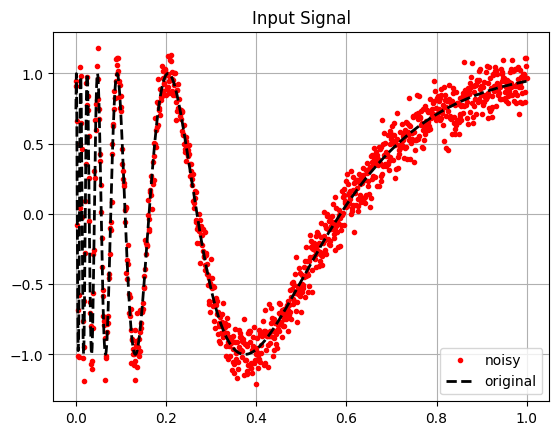

In [420]:
plt.figure()
plt.plot(ty, s, 'r.')
plt.plot(ty, y, 'k--', linewidth=2)
plt.grid()
plt.legend(['noisy', 'original'])
plt.title('Input Signal')

Define the matrix T containing the polynomials sampled over the window

$$
T=
\begin{bmatrix}
    1 & t_1 & t_1^2 & \dots & t_1^N \\ 
    1 & t_2 & t_2^2 & \dots & t_2^N \\
    \vdots & \vdots & \vdots & & \vdots \\
    1 & t_M & t_M^2 & \dots & t_M^N
\end{bmatrix}
$$

In [421]:
t = np.linspace(0, 1, M)
T = np.array([t**i for i in range(N+1)]).T

# print the shape of T, it should be (M, N+1)
print(f"The shape of T is {T.shape}. It should be (M, N+1) = ({M}, {N+1}).")

The shape of T is (51, 3). It should be (M, N+1) = (51, 3).


Look at the matrix T, the columns correspond to polynomials sampled over the interval [0,1]


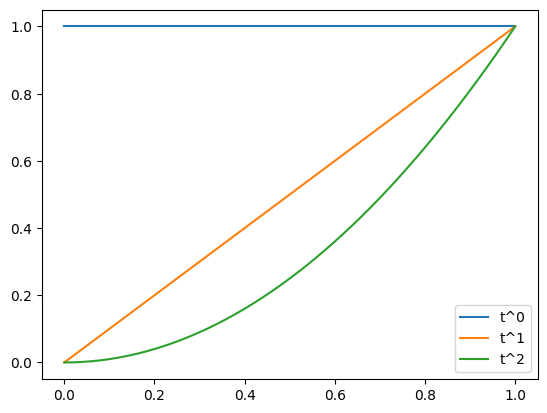

In [422]:
plt.figure()
leg = []
for l in range(N+1):
    plt.plot(t, T[:, l])
    leg.append(f't^{l:d}')
plt.legend(leg)

Construct the LPA kernel

In [423]:
# comput the qr decomposition of T
# since T has more rows than columns, then qr computes only the first (N + 1) columns of Q and the first (N + 1) rows of R.
Q, R = np.linalg.qr(T, mode='reduced')

print(f"The shape of Q is {Q.shape}. It should be (M, N+1) = ({M}, {N+1}).")

# select the central row of Q, corresponding to the center of the local window
central_row = M // 2

print(f"The index of the central row is {central_row}.")

# compute the kernel
g = np.zeros(M)
for i in range(N+1):
    g += Q[central_row, i] * Q[:, i] 

# flipping, since it is used in convolution
g = np.flip(g)

The shape of Q is (51, 3). It should be (M, N+1) = (51, 3).
The index of the central row is 25.


Text(0.5, 1.0, 'M = 51, N = 2')

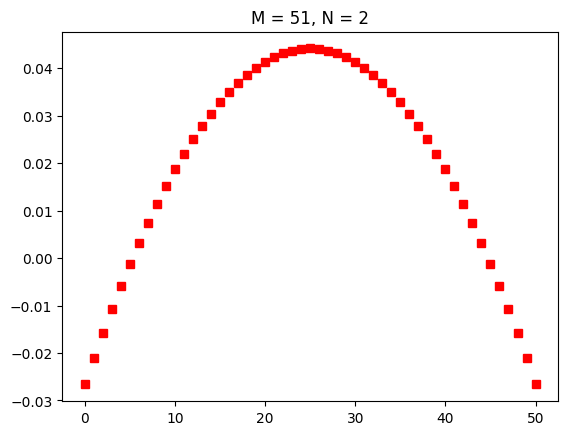

In [424]:
plt.figure()
plt.plot(g, 'rs', linewidth=3)
plt.title(f'M = {M:d}, N = {N:d}')

Filtering

In [425]:
shat = convolve(s, g, mode='same')

Text(0.5, 1.0, 'M = 51, N = 2')

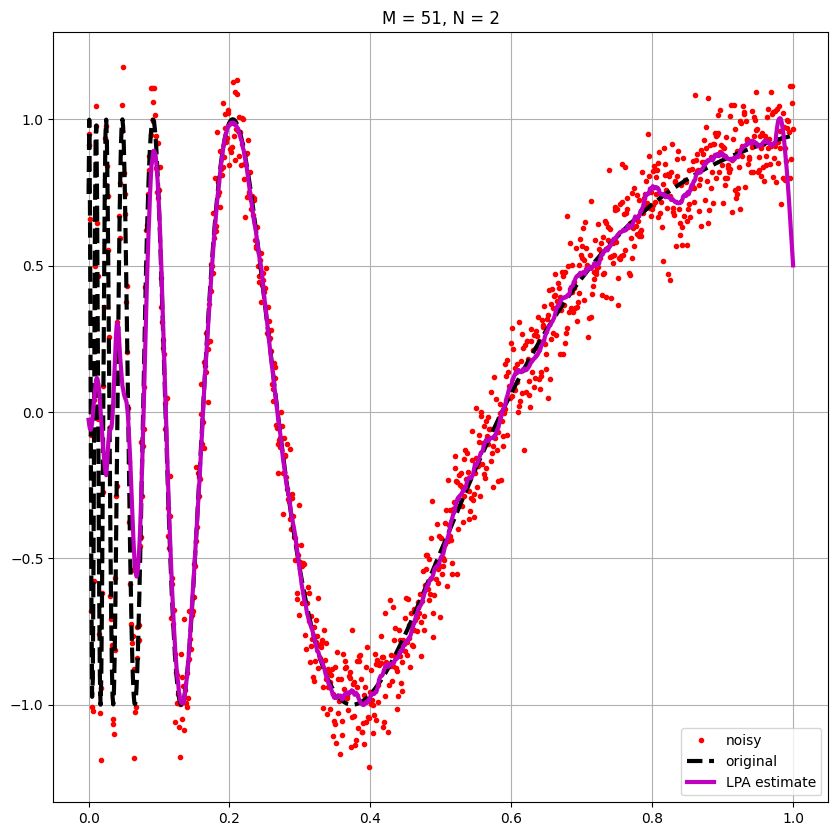

In [426]:
plt.figure(figsize=(10,10))
plt.plot(ty, s, 'r.')
plt.plot(ty, y, 'k--', linewidth=3)
plt.plot(ty, shat, 'm-', linewidth=3)
plt.grid()
plt.legend(['noisy', 'original', 'LPA estimate'])
plt.title(f'M = {M:d}, N = {N:d}')

Weighted LPA
--------------
Set the parameters

In [427]:
# maximum degree of polynomial used for fitting
N = 1

# filter size
M = 53

# half filter size
HFS = int((M-1) / 2)

# set the weights. Here weights simply define the window size
w = np.zeros(M)

# centered kernel
wc = w.copy()
wc[int(HFS/2) : -int(HFS/2)] = 1

# left kernel
wl = w.copy()
wl[:HFS+1] = 1

# right kernel
wr = w.copy()
wr[-HFS-1:] = 1

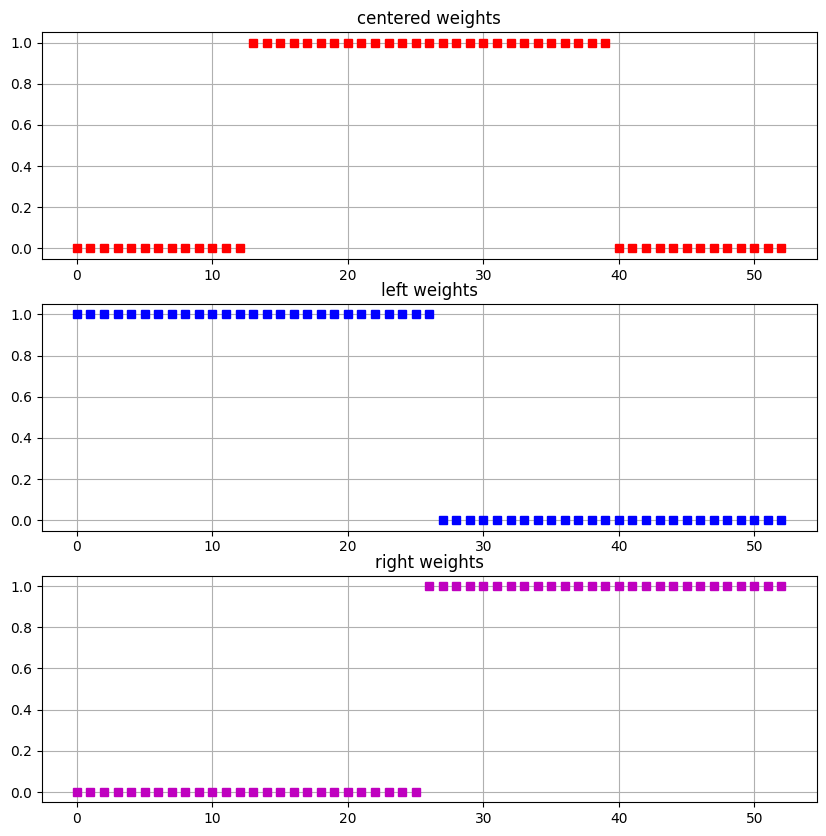

In [428]:
fig, ax = plt.subplots(3, 1, figsize=(10,10))
ax[0].plot(wc, 'rs', linewidth=3)
ax[0].set_title('centered weights')
ax[0].grid()
ax[1].plot(wl, 'bs', linewidth=3)
ax[1].set_title('left weights')
ax[1].grid()
ax[2].plot(wr, 'ms', linewidth=3)
ax[2].set_title('right weights')
ax[2].grid()

Build the weight matrix

In [429]:
# select a single weight to be used in what follows
w = wc.copy()

# generate the inverse of weights
winv = np.zeros_like(w, dtype=float)
np.divide(1.0, w, out=winv, where=(w != 0))

# define the weight matrix
W = np.diag(w)
Winv = np.diag(winv)

Generate synthetic signal signal

In [430]:
LENGTH = 1000

# clean signal
ty = np.linspace(0, 1, LENGTH)
y =  8*ty**2 - 2*ty + 2
y[LENGTH//2 : LENGTH] = y[LENGTH//2 : LENGTH] + 7

# noise standard deviation
sigma = 0.2

# noisy signal
s = y + sigma*np.random.normal(size=LENGTH)

Text(0.5, 1.0, 'Input Signal')

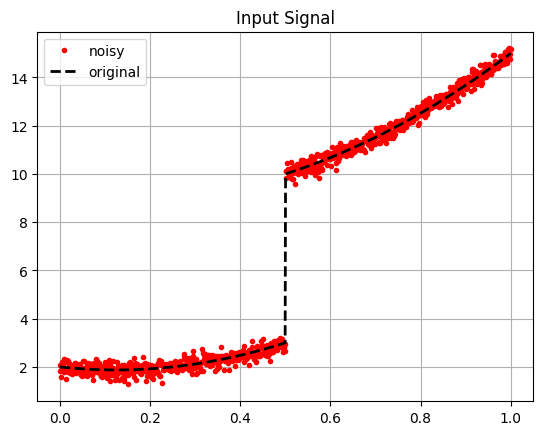

In [431]:
plt.figure()
plt.plot(ty, s, 'r.')
plt.plot(ty, y, 'k--', linewidth=2)
plt.grid()
plt.legend(['noisy', 'original'])
plt.title('Input Signal')

Define the matrix T containing the polynomials sampled over the window

In [432]:
t = np.linspace(0, 1, M) 
T = np.array([t**i for i in range(N+1)]).T

Construct the LPA kernel

In [433]:
# comput the qr decomposition of WT
# since T has more rows than columns, then qr computes only the first (N + 1) columns of Q and the first (N + 1) rows of R.
Q, R = np.linalg.qr(W @ T, mode='reduced')

# define Qtilde
Qtilde = Winv @ Q

print(f"The shape of Qtilde is {Qtilde.shape}. It should be (M, N+1) = ({M}, {N+1}).")

# adjust Qtilde with the weights matrix squared
W2Qtilde = (W @ W) @ Qtilde

# select the central row of Qtilde
central_row = M // 2
print(f"The index of the central row is {central_row}.")

# compute the kernel
g = np.zeros(M)
for i in range(N+1):
    g += Qtilde[central_row, i] * W2Qtilde[:, i]

# flipping, since it is used in convolution
g = np.flip(g)

The shape of Qtilde is (53, 2). It should be (M, N+1) = (53, 2).
The index of the central row is 26.


Text(0.5, 1.0, 'filter M = 53, N = 1')

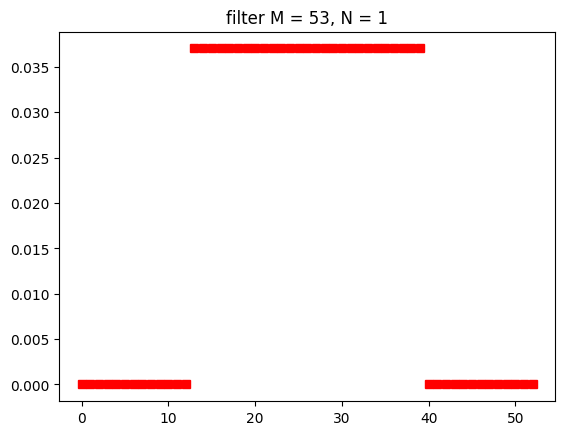

In [434]:
plt.figure()
plt.plot(g, 'rs', linewidth=3)
plt.title(f'filter M = {M:d}, N = {N:d}')

Filtering


In [435]:
shat = convolve(s, g, mode='same')

Text(0.5, 1.0, 'M = 53, N = 1')

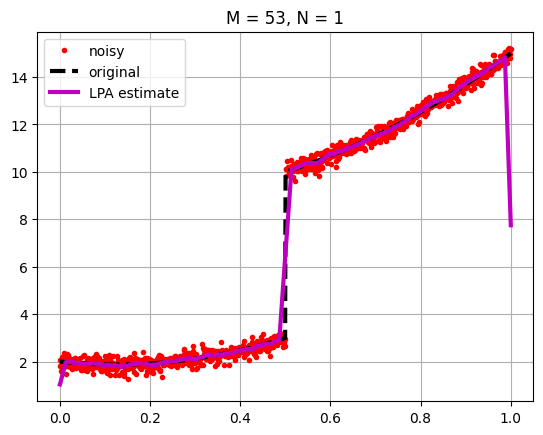

In [436]:
plt.figure()
plt.plot(ty, s, 'r.')
plt.plot(ty, y, 'k--', linewidth=3)
plt.plot(ty, shat, 'm-', linewidth=3)
plt.grid()
plt.legend(['noisy', 'original', 'LPA estimate'])
plt.title(f'M = {M:d}, N = {N:d}')

Modify the code to use the central, left and right kernels

In [437]:
def compute_weight(w_ref):
    w = w_ref.copy()

    w_inv = np.zeros_like(w, dtype=float)
    np.divide(1.0, w, out=w_inv, where=(w != 0))

    W = np.diag(w)
    Winv = np.diag(w_inv)

    return W, Winv

def compute_kernel(T, W, Winv, N):
    M = T.shape[0]

    Q, _ = np.linalg.qr(W @ T, mode='reduced')

    Qtilde = Winv @ Q

    W2Qtilde = (W @ W) @ Qtilde

    central_row = M // 2

    g = np.zeros(M)
    for i in range(N + 1):
        g += Qtilde[central_row, i] * W2Qtilde[:, i]

    g = np.flip(g)

    return g

# store all cases in a dictionary
weight_dict = {
    'left': wl,
    'center': wc,
    'right': wr
}

results = {}

for name, w_ref in weight_dict.items():
    W, Winv = compute_weight(w_ref)
    g = compute_kernel(T, W, Winv, N)
    shat = convolve(s, g, mode='same')

    results[name] = {
        'g': g,
        'shat': shat
    }

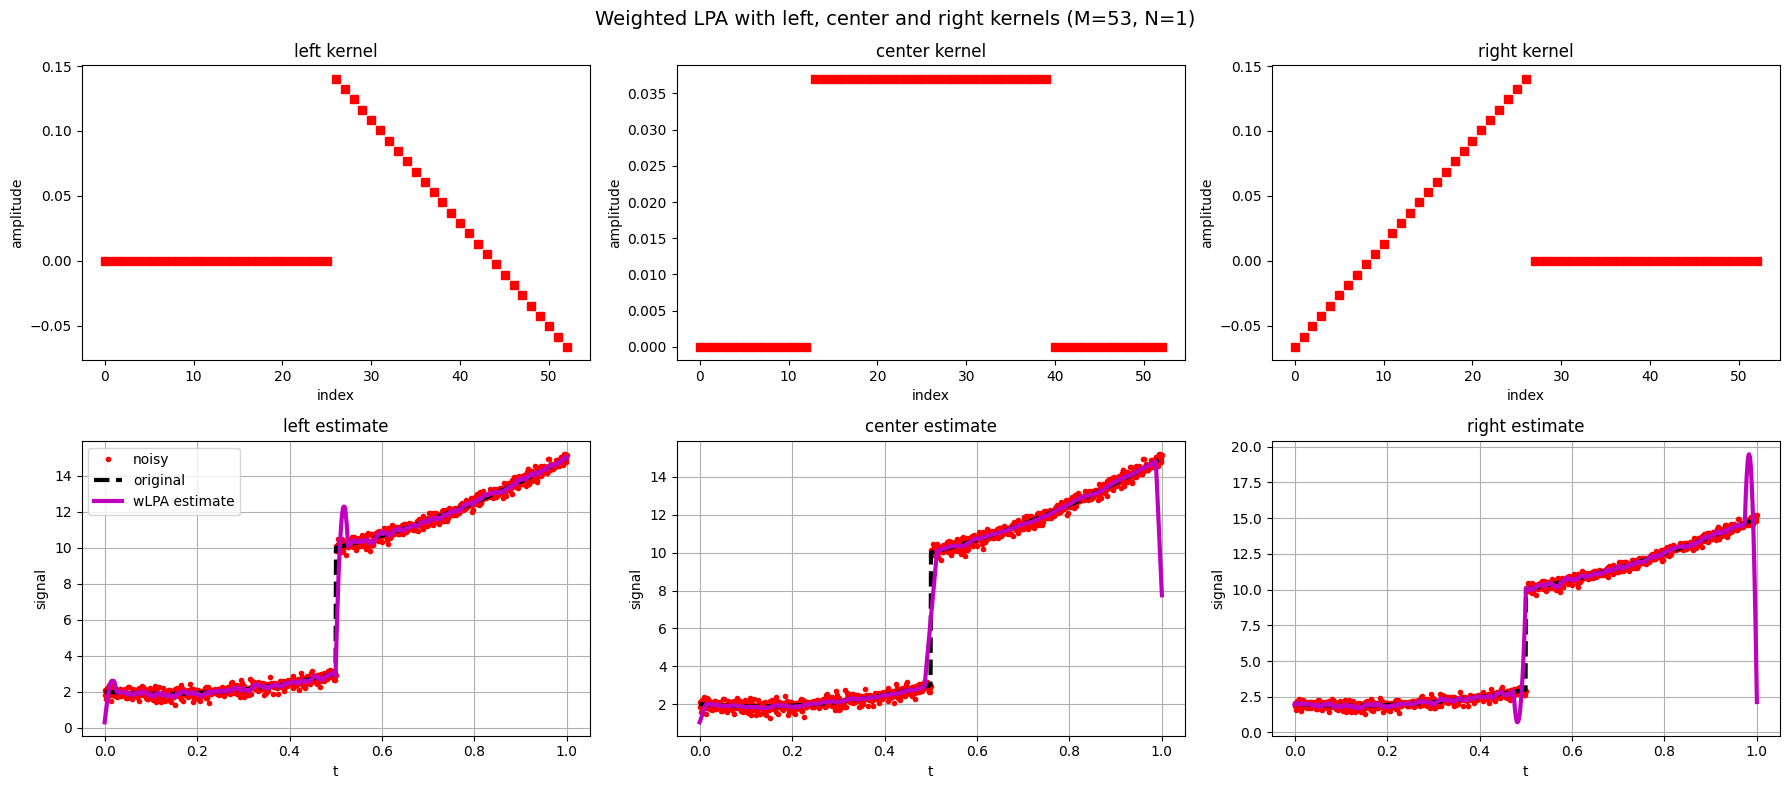

In [438]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex='row')

case_names = ['left', 'center', 'right']

for j, name in enumerate(case_names):
    g = results[name]['g']
    shat = results[name]['shat']

    # first row: kernels
    ax = axes[0, j]
    ax.plot(g, 'rs', linewidth=3)
    ax.set_title(f'{name} kernel')
    ax.set_xlabel('index')
    ax.set_ylabel('amplitude')
    
    # second row: estimates
    ax = axes[1, j]
    ax.plot(ty, s, 'r.', label='noisy')
    ax.plot(ty, y, 'k--', linewidth=3, label='original')
    ax.plot(ty, shat, 'm-', linewidth=3, label='wLPA estimate')
    ax.set_title(f'{name} estimate')
    ax.set_xlabel('t')
    ax.set_ylabel('signal')
    ax.grid(True)

    if j == 0:
        ax.legend()

plt.suptitle(f'Weighted LPA with left, center and right kernels (M={M}, N={N})', fontsize=14)
plt.tight_layout()
plt.show()

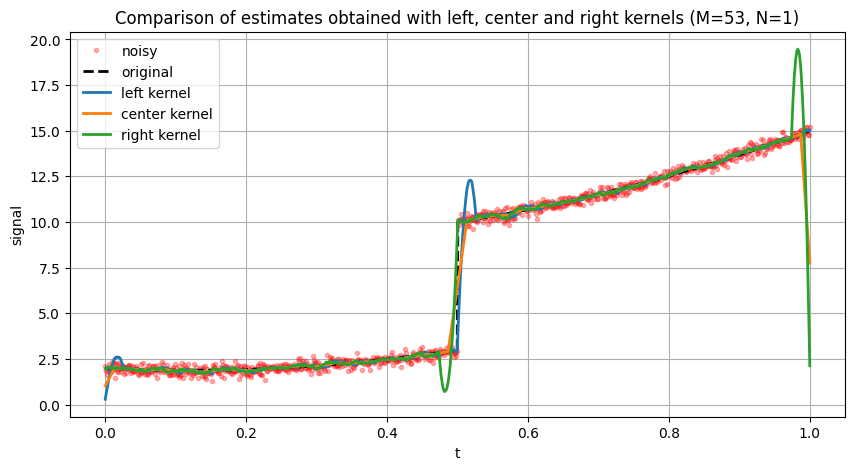

In [439]:
plt.figure(figsize=(10, 5))
plt.plot(ty, s, 'r.', alpha=0.3, label='noisy')
plt.plot(ty, y, 'k--', linewidth=2, label='original')
plt.plot(ty, results['left']['shat'], linewidth=2, label='left kernel')
plt.plot(ty, results['center']['shat'], linewidth=2, label='center kernel')
plt.plot(ty, results['right']['shat'], linewidth=2, label='right kernel')
plt.grid(True)
plt.legend()
plt.title(f'Comparison of estimates obtained with left, center and right kernels (M={M}, N={N})')
plt.xlabel('t')
plt.ylabel('signal')
plt.show()